# Weekly report — 2026-05-27 · ball-rollers

Two parts:
1. **PolyFEM data generation** for the large ball-rollers mesh (`2568220` rows): speed, projected total time, storage strategy, and an MPI-vs-OMP acceleration test.
2. **Benchmark result**: elapsed time vs matrix size for the ball-rollers dataset.

## Part 1 — ball-rollers PolyFEM data generation

### 1.1 Generation speed for the `2568220`-row mesh, and projected total time

Source: `ball_rollers/result_10000-2568220-small-small-resume-resume/2568220/debug_log.txt`.
PolyFEM uses Hypre (BoomerAMG + PCG, OpenMP) as its linear solver. Per Newton iteration the log records `assembly` + `linear_solve` time:

| step | iter | assembly | linear_solve | total |
|---:|---:|---:|---:|---:|
| 1 | 1 | 520 s | 421 s | 941 s |
| 2 | 1 | 136 s | 439 s | 575 s |
| 3 | 1 | 126 s | 375 s | 501 s |
| 4 | 1 | 135 s | 394 s | 529 s |
| 5 | 1 | 123 s | 448 s | 571 s |
| 6 | 1 | 133 s | 440 s | 573 s |
| 7 | 1 | 118 s | 377 s | 495 s |
| 8 | 1 | 129 s | 393 s | 522 s |

So far it has reached **step 8** (one Newton iter each — these early steps have no contact yet). Representative cost is **~540 s / Newton iter** (the linear solve alone is ~400 s; step 1's assembly is a one-time 520 s outlier). The `linear_solve` term dominates — which is exactly the part MPI could accelerate (§1.3).

#### Projected total time for the full 30-step run

We don't yet have 30 steps for `2568220`, so we borrow the **per-step Newton-iteration counts from the completed `9996` run** (`result_10000-2568220-small-small/9996`, which ran all 30 steps). Its iteration counts explode once contact engages:

```
step:  1  2  3  4  5  6  7  8   9  10  11  12  13  14  15  16  17  18  19  20 ...
iter:  1  3  4  4  4  4  3  3  29  52  54  88  95 106 110 153 101 212 402 312 ...
```

- Total Newton iterations across 30 steps (from `9996`): **4791**
- Max iterations in a single step: **490** (step 28)

Estimated wall time for `2568220` to finish 30 steps, assuming the same iteration structure and ~540 s/iter:

> **4791 iters × 540 s ≈ 2.59 × 10⁶ s ≈ 719 hours ≈ ~30 days**

That is clearly impractical as-is — motivating both the storage strategy (§1.2) and the MPI acceleration (§1.3).

In [4]:
# Reproduce the 30-step time projection
per_iter_s = 540          # representative Newton-iter cost for 2568220 (linear_solve-dominated)
total_iters_9996 = 4791   # total Newton iters across 30 steps, from the 9996 reference run
max_iters_step = 490      # most iterations in any single step (step 28)

est_s = total_iters_9996 * per_iter_s
print(f"projected total: {est_s:.3e} s = {est_s/3600:.0f} h = {est_s/3600/24:.1f} days")

projected total: 2.587e+06 s = 719 h = 29.9 days


### 1.2 Storage strategy — peak usage on disk

For `2568220` each dumped `A.bin` is **5.53 GB** (3D elasticity, ~2.57 M rows). Dumping every Newton iteration without cleanup is infeasible. Three strategies:

- **No cleaning** — keep every matrix. Peak = `matrix_size × total_iters`.
- **Per-step cleaning** — after each step finishes, randomly draw 5 % of that step's iterations and delete the rest; after all 30 steps, draw the target count and delete the rest. Peak = `matrix_size × (max iterations in any single step)` (one step's matrices pile up before they're pruned).
- **Per-iteration cleaning** — decide immediately after each iteration whether to keep it (5 % probability), delete otherwise; draw the target at the end. A full step's matrices never accumulate, so peak = `matrix_size × (5 % of total_iters)`.

| strategy | peak # matrices | peak storage | fits 15 TB disk? |
|---|---:|---:|:-:|
| no cleaning | 4791 | **25.9 TB** | ❌ |
| per-step cleaning | 490 | **2.65 TB** | ✅ |
| **per-iteration cleaning** | 240 | **1.30 TB** | ✅ (lowest) |

**Per-iteration cleaning is the lowest-peak option** (1.30 TB vs 2.65 TB), because it never lets a single contact-heavy step's matrices pile up on disk. The trade-off is you commit to keep/discard before seeing the rest of the step, but for a uniform-random 5 % sample that's statistically equivalent.

In [5]:
# Reproduce the storage peaks
A_bin_GB = 5.53           # one A.bin for the 2568220 mesh
total_iters = 4791
max_iters_step = 490
keep_frac = 0.05

no_clean   = total_iters            * A_bin_GB
per_step   = max_iters_step         * A_bin_GB
per_iter   = keep_frac*total_iters  * A_bin_GB
for name, gb in [("no cleaning", no_clean), ("per-step", per_step), ("per-iteration", per_iter)]:
    print(f"  {name:16}: {gb/1000:.2f} TB  ({gb:.0f} GB,  {gb/A_bin_GB:.0f} matrices)")

  no cleaning     : 26.49 TB  (26494 GB,  4791 matrices)
  per-step        : 2.71 TB  (2710 GB,  490 matrices)
  per-iteration   : 1.32 TB  (1325 GB,  240 matrices)


### 1.3 Acceleration: MPI multi-process Hypre vs OMP multi-thread Hypre

The generation cost is dominated by Hypre's `linear_solve` (~400 s/iter on `2568220`). PolyFEM currently runs Hypre with **OpenMP threads** (`mpi_size = 1`). Classical BoomerAMG threads poorly; switching to **MPI multi-process** Hypre could scale much better.

**Test** (following the env conventions in `test_larger_mat_multithread_no_taskset_mpi_parallel-5-27.py`): same matrix `result_10000-2568220-small-small/9996/10_45_A.bin` (mat_sz = 31 824), `tol = 1e-10`.
- **Hypre OMP** → `OMP_NUM_THREADS=N`, direct call, `numactl` bind when `N=1`.
- **Hypre_mpi** → `OMP_NUM_THREADS=1`, `mpirun -np N`.

| cores | Hypre OMP (elapse) | Hypre_mpi (elapse) |
|---:|---:|---:|
| 1 | 2.59 s | 4.65 s |
| 2 | 2.89 s | 2.17 s |
| 4 | 2.41 s | 1.71 s |
| 8 | **1.61 s** | **0.89 s** |
| **speedup 1→8** | **1.6×** | **5.2×** |

- **OMP barely scales** (1.6× from 1→8 threads) — BoomerAMG's OpenMP parallelism is weak.
- **MPI scales 5.2×** and at 8 cores is **~1.8× faster than OMP=8**.
- MPI's `np=1` is slower than OMP's 1-thread (singleton-MPI overhead + full-matrix replication), so the crossover is at `np ≥ 2`.

**Conclusion:** for generating the large meshes, switching PolyFEM's Hypre from OMP to MPI multi-process should give a meaningful speedup on the linear solve (the bottleneck), and the gap widens with more cores. The 31 824-row test understates it — at 2.57 M rows there is far more work per rank to amortize MPI communication.

**Caveat (cross-ref 2026-05-21 notebook):** MPI Hypre at `np ≥ 3` hits the *Subnormal gamma* failure on contact-heavy (ill-conditioned) matrices with the default `row_block + pcg + boomeramg` stack. To use MPI Hypre for generation we'd need the robust config (`+ euclid`, or `metis + gmres`). So the acceleration and the subnormal fix are coupled.

In [6]:
# Reproduce the scaling table + speedups
omp  = {1: 2.589, 2: 2.8863, 4: 2.4111, 8: 1.6058}
mpi  = {1: 4.6529, 2: 2.165, 4: 1.7103, 8: 0.89425}
print(f"{'cores':>5} {'OMP (s)':>9} {'MPI (s)':>9}")
for n in (1,2,4,8):
    print(f"{n:>5} {omp[n]:>9.2f} {mpi[n]:>9.2f}")
print(f"\nOMP speedup 1->8: {omp[1]/omp[8]:.2f}x")
print(f"MPI speedup 1->8: {mpi[1]/mpi[8]:.2f}x")
print(f"MPI vs OMP at 8 cores: {omp[8]/mpi[8]:.2f}x faster")

cores   OMP (s)   MPI (s)
    1      2.59      4.65
    2      2.89      2.17
    4      2.41      1.71
    8      1.61      0.89

OMP speedup 1->8: 1.61x
MPI speedup 1->8: 5.20x
MPI vs OMP at 8 cores: 1.80x faster


## Part 2 — ball-rollers benchmark result

Elapsed time vs matrix size for the ball-rollers dataset, same plotting style as
`analysis_2026-4-22_ball_rollers.ipynb`. Data:
`larger_mat_exp_result/2026-5-27/ball-rollers/ball_rollers_8` (4 solvers × 13 mesh sizes,
`OMP=8` for OMP solvers / `mpirun -np 8` for MPI solvers).

In [9]:
import os, sys, re, contextlib, io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib

sys.path.insert(0, '/u/1/chenyang/benchmark/analysis')
import libs.parser; importlib.reload(libs.parser)
from libs.parser import parse_log_file

SOLVER_COLORS = {
    'AMGCL':              '#d62728',
    'Eigen::PardisoLDLT': '#1f77b4',
    'Hypre_mpi':          '#2ca02c',
    'Trilinos':           '#ff7f0e',
}
SOLVER_PREFIXES = sorted(SOLVER_COLORS.keys(), key=len, reverse=True)
DATA_SOURCE_NOTE = 'Matrices: PolyFEM forced PSD  ·  mesh: ball_rollers/result_10000-2568220-small-small'

LOG_DIR = ('/u/1/chenyang/benchmark_data/larger_matrix_exp/larger_mat_exp_result/'
           '2026-5-27/ball-rollers/ball_rollers_8')


def load_all_logs(log_dir):
    rows = []
    for fname in sorted(os.listdir(log_dir)):
        if not fname.endswith('.log'):
            continue
        solver = next((p for p in SOLVER_PREFIXES if fname.startswith(p + '_')), None)
        if solver is None:
            continue
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            try:
                entries = parse_log_file(os.path.join(log_dir, fname), solver)
            except Exception as ex:
                print(f'skip {fname}: {ex}')
                continue
        for e in entries:
            if e.get('mat_sz') and e.get('elapse_time'):
                rows.append({'solver': solver, 'mat_sz': e['mat_sz'],
                             'elapse_time': e['elapse_time'],
                             'num_iterations': e.get('num_iterations')})
    return pd.DataFrame(rows)


def plot_time_vs_mat_sz(df, title, figsize=(10, 6)):
    fig, ax = plt.subplots(figsize=figsize)
    for solver in SOLVER_PREFIXES:
        g = df[df['solver'] == solver]
        if g.empty:
            continue
        color = SOLVER_COLORS[solver]
        ax.scatter(g['mat_sz'], g['elapse_time'], s=16, alpha=0.5, color=color,
                   label=f'{solver} (n={len(g)})')
        gm = g.groupby('mat_sz')['elapse_time'].mean().reset_index().sort_values('mat_sz')
        if len(gm) >= 3:
            lx, ly = np.log10(gm['mat_sz']), np.log10(gm['elapse_time'])
            slope, intercept = np.polyfit(lx, ly, 1)
            xf = np.logspace(lx.min(), lx.max(), 200)
            ax.plot(xf, 10**(slope*np.log10(xf)+intercept), '--', color=color, lw=1.5, alpha=0.8,
                    label=f'  fit (slope={slope:.2f})')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('Matrix Size (rows, log scale)', fontsize=12)
    ax.set_ylabel('Elapse Time (s, log scale)', fontsize=12)
    ax.set_title(f'{title}\n{DATA_SOURCE_NOTE}  ·  fit = log-linear on mean per mat_sz', fontsize=11)
    ax.legend(fontsize=9, loc='upper left', ncol=2)
    ax.grid(True, which='both', alpha=0.3)
    plt.tight_layout()
    return fig, ax

print('Log dir:', LOG_DIR)
print('Files:  ', len(os.listdir(LOG_DIR)))

Log dir: /u/1/chenyang/benchmark_data/larger_matrix_exp/larger_mat_exp_result/2026-5-27/ball-rollers/ball_rollers_8
Files:   54


entries: 803
                      n  mat_min  mat_max     t_mean
solver                                              
AMGCL               219    31824  2619000  70.154198
Eigen::PardisoLDLT  195    31824   687990  29.504032
Hypre_mpi           178    31824  2619000  42.067184
Trilinos            211    31824  2619000  55.337314


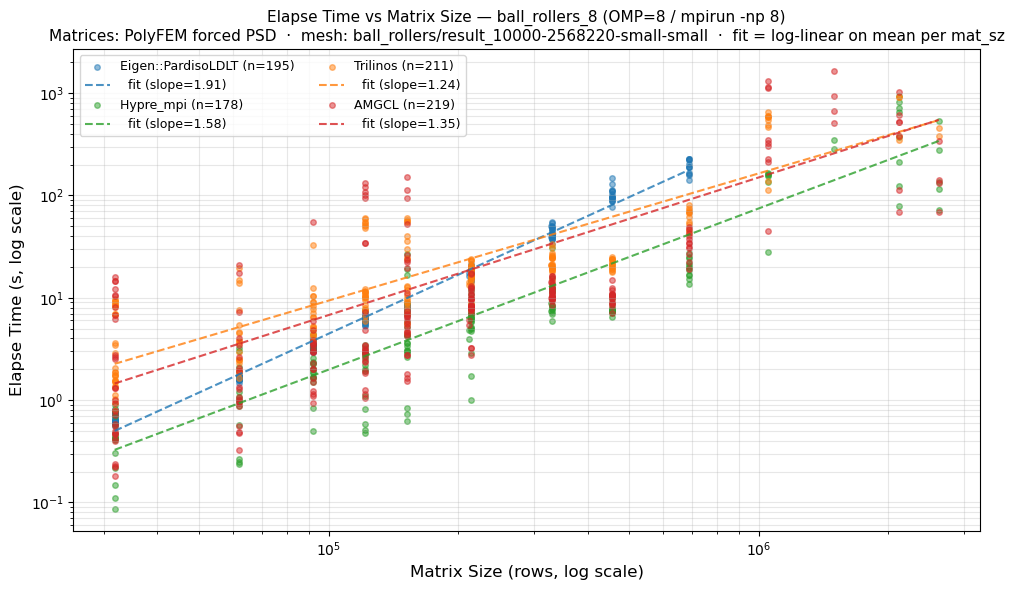

In [8]:
df = load_all_logs(LOG_DIR)
print(f'entries: {len(df)}')
print(df.groupby('solver').agg(n=('mat_sz','size'),
                               mat_min=('mat_sz','min'), mat_max=('mat_sz','max'),
                               t_mean=('elapse_time','mean')))

fig, ax = plot_time_vs_mat_sz(df, 'Elapse Time vs Matrix Size — ball_rollers_8 (OMP=8 / mpirun -np 8)')
plt.show()